#Tech Challenge - Fase 4: Sistema de Análise de Vídeo Inteligente

Este notebook implementa uma aplicação completa de análise de vídeo, integrando múltiplas técnicas de Inteligência Artificial e Visão Computacional para extração de métricas comportamentais e detecção de padrões.

###Funcionalidades Principais
- Reconhecimento Facial: Localização e marcação em tempo real de rostos no vídeo utilizando algoritmos de detecção baseados em OpenCV.
- Análise de Expressões: Classificação automática das emoções dominantes (Ex: Feliz, Neutro, Triste) através da biblioteca DeepFace.
- Detecção de Atividades: Monitorização do nível de movimento e categorização da atividade com base em algoritmos de fluxo óptico e velocidade vetorial.
- Monitorização de Anomalias: Identificação de movimentos anômalos, definidos como gestos bruscos ou comportamentos que fogem ao padrão estatístico da cena.

###Pré requisitos
- Fazer upload do vídeo para este ambiente de execução

1. Instalação de bibliotecas

In [ ]:
!pip install opencv-python deepface tf-keras numpy
!apt-get update && apt-get install -y libgl1-mesa-glx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.1/133.1 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 109.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 5.2 MB/s eta 0:00:00
Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,233 kB]
Get:5 https://cli.github.com/packages stable/main amd64 Packages [345 B]
Get:6 http://security

In [ ]:
import cv2
from deepface import DeepFace
import numpy as np
import os
from google.colab.patches import cv2_imshow
from collections import Counter, deque
import collections
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import seaborn as sns
from datetime import datetime

26-01-09 23:01:49 - Directory /root/.deepface has been created
26-01-09 23:01:49 - Directory /root/.deepface/weights has been created


2. Classe para análise do vídeo

In [ ]:
class VideoAnalyzer:
    def __init__(self):
        self.detector_backend = 'retinaface'
        self.prev_frame_gray = None
        self.frame_count = 0
        self.total_anomalies = 0
        self.total_faces_count = 0
        self.emotions_history = []
        self.activities_history = []
        self.motion_history = collections.deque(maxlen=150)
        self.scene_cut_threshold = 30.0
        self.sensitivity_k = 3.0

    def _improve_contrast(self, frame):
        lab = cv2.cvtColor(frame, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
        cl = clahe.apply(l)
        return cv2.cvtColor(cv2.merge((cl,a,b)), cv2.COLOR_LAB2BGR)

    def analyze_frame(self, frame):
        self.frame_count += 1
        processed_frame = self._improve_contrast(frame)
        results = {"faces": [], "emotions": [], "activity": "Static", "anomaly": False, "score": 0.0}

        try:
            face_objs = DeepFace.analyze(
                img_path=processed_frame,
                actions=['emotion'],
                detector_backend=self.detector_backend,
                enforce_detection=False,
                silent=True
            )
            for face in face_objs:
                if face['face_confidence'] > 0.4:
                    region = face['region']
                    results["faces"].append((region['x'], region['y'], region['w'], region['h']))
                    emotion = face['dominant_emotion']
                    results["emotions"].append(emotion)
                    self.emotions_history.append(emotion)
                    self.total_faces_count += 1
        except Exception: pass

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        if self.prev_frame_gray is not None:
            diff = cv2.absdiff(self.prev_frame_gray, gray)
            motion_score = np.mean(diff)

            if motion_score < self.scene_cut_threshold:
                self.motion_history.append(motion_score)
                if len(self.motion_history) > 30:
                    avg = np.mean(self.motion_history)
                    std = np.std(self.motion_history) + 0.001
                    z_score = abs(motion_score - avg) / std
                    results["score"] = z_score

                    if z_score > self.sensitivity_k and motion_score > 2.0:
                        results["activity"] = "Excessive Motion"
                        results["anomaly"] = True
                        self.total_anomalies += 1
                    elif motion_score > 1.0:
                        results["activity"] = "Moderate Activity"

            self.activities_history.append(results["activity"])

        self.prev_frame_gray = gray
        return results

    def draw_results(self, frame, results):
        # 1. Desenhar retângulos e emoções sobre cada rosto
        for i, (x, y, w, h) in enumerate(results["faces"]):
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 255), 2)
            if i < len(results["emotions"]):
                emo_text = results["emotions"][i].capitalize()
                cv2.putText(frame, emo_text, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        # 2. Configurações do painel superior esquerdo (HUD)
        color_info = (255, 255, 255) # Branco para informações gerais
        color_activity = (0, 0, 255) if results["anomaly"] else (0, 255, 0)

        # Linha 1: Atividade
        cv2.putText(frame, f"Activity: {results['activity']}", (20, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color_activity, 2)

        # Linha 2: Quantidade de rostos detectados no frame
        num_faces = len(results["faces"])
        cv2.putText(frame, f"Faces detected: {num_faces}", (20, 70),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, color_info, 2)

        # Linha 3: Lista de emoções presentes no frame
        if results["emotions"]:
            # Criamos uma string com as emoções capitalizadas separadas por vírgula
            emos_str = ", ".join([e.capitalize() for e in results["emotions"]])
            # Se a lista for muito longa, podemos truncar para não sair da tela
            display_text = f"Emotions: {emos_str}"
            if len(display_text) > 50: display_text = display_text[:47] + "..."

            cv2.putText(frame, display_text, (20, 100),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color_info, 2)

        # Linha 4: Alerta de Anomalia (se existir)
        if results["anomaly"]:
            cv2.putText(frame, f"ANOMALY DETECTED (Z:{results['score']:.1f})", (20, 130),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

        return frame

    def generate_summary(self):
        emo_counts = Counter(self.emotions_history)
        act_counts = Counter(self.activities_history)
        dom_emo = emo_counts.most_common(1)[0][0] if emo_counts else "N/A"
        print("\n" + "="*50)
        print("           RELATÓRIO DE ANÁLISE FINAL             ")
        print("="*50)
        print(f"📊 ESTATÍSTICAS GERAIS:")
        print(f"   • Total de frames analisados: {self.frame_count}")
        print(f"   • Total de rostos detectados: {self.total_faces_count}")
        print(f"   • Total de anomalias detectadas: {self.total_anomalies}")
        print(f"   • Emoção predominante: {dom_emo.upper()}")
        print("-" * 50)

        # 2. Geração dos Gráficos
        plt.figure(figsize=(15, 6))

        # Gráfico de Emoções

        plt.subplot(1, 2, 1)
        if emo_counts:
            sns.barplot(x=list(emo_counts.keys()), y=list(emo_counts.values()), palette="viridis")
        plt.title("Distribuição de Emoções")
        plt.ylabel("Frequência (Deteções)")
        plt.xticks(rotation=45)

        # Gráfico de Atividades

        plt.subplot(1, 2, 2)
        if act_counts:
            sns.barplot(x=list(act_counts.keys()), y=list(act_counts.values()), palette="magma")
        plt.title("Distribuição de Atividades")
        plt.ylabel("Frequência (Frames)")
        plt.xticks(rotation=45)

        plt.tight_layout()
        # Salva o gráfico como imagem
        plt.savefig('graficos_relatorio.png')
        plt.show()

        print(f"📈 Gráficos salvos como: graficos_relatorio.png")
        print("="*50)

3. Execução da análise

🎬 Iniciando processamento de 3326 frames...


Processando:   0%|          | 0/3326 [00:00<?, ?it/s]

26-01-09 23:01:54 - retinaface.h5 will be downloaded from the url https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/retinaface.h5
To: /root/.deepface/weights/retinaface.h5

  0%|          | 0.00/119M [00:00<?, ?B/s]
 38%|███▊      | 45.6M/119M [00:00<00:00, 453MB/s]
100%|██████████| 119M/119M [00:00<00:00, 501MB/s]


26-01-09 23:02:00 - 🔗 facial_expression_model_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5 to /root/.deepface/weights/facial_expression_model_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facial_expression_model_weights.h5
To: /root/.deepface/weights/facial_expression_model_weights.h5

100%|██████████| 5.98M/5.98M [00:00<00:00, 419MB/s]



✅ Análise salva em: /content/video_analisado.mp4

           RELATÓRIO DE ANÁLISE FINAL             
📊 ESTATÍSTICAS GERAIS:
   • Total de frames analisados: 3326
   • Total de rostos detectados: 4488
   • Total de anomalias detectadas: 73
   • Emoção predominante: SAD
--------------------------------------------------


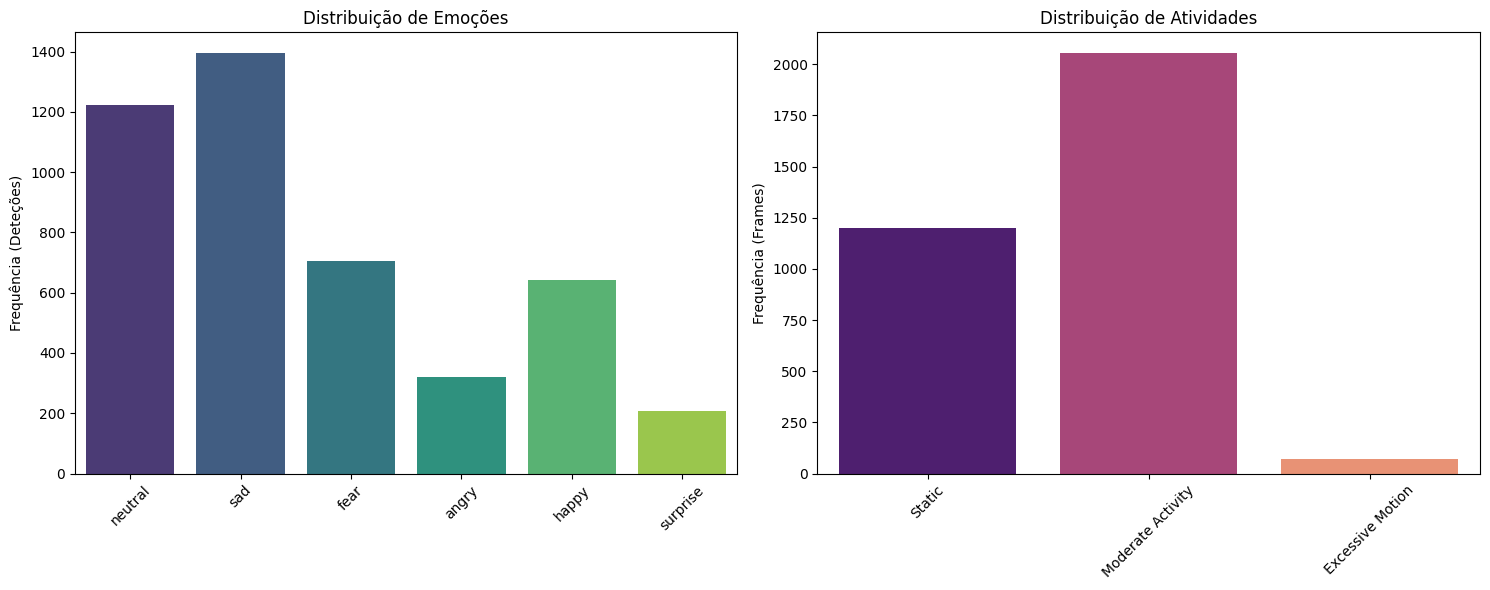

📈 Gráficos salvos como: graficos_relatorio.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def main():
    video_path = "/content/Unlocking Facial Recognition_ Diverse Activities Analysis.mp4"
    output_path = "/content/video_analisado.mp4"

    if not os.path.exists(video_path):
        print(f"ERRO: vídeo não encontrado em {video_path}")
        return

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"ERRO: não foi possível abrir o vídeo")
        return

    analyzer = VideoAnalyzer()
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    print(f"🎬 Iniciando processamento de {total_frames} frames...")

    # Barra de progresso para acompanhar o tempo
    for _ in tqdm(range(total_frames), desc="Processando"):
        ret, frame = cap.read()
        if not ret:
            break

        results = analyzer.analyze_frame(frame)
        output_frame = analyzer.draw_results(frame, results)
        out.write(output_frame)

    cap.release()
    out.release()
    print(f"\n✅ Análise salva em: {output_path}")

    # Gera o resumo com gráficos
    analyzer.generate_summary()

    from google.colab import files
    files.download(output_path)

if __name__ == "__main__":
    main()